# SPI-TAP non-interactive run

## Selections and directory build

In [ ]:
import os
import spitap.spi_obs as st

# absolute path to all analysis results
obsdir = "/home/tbouchet/spi-tap/obs"
initial_dir = "/home/tbouchet/spi-tap" # REPLACE WITH LOCATION OF NOTEBOOK
# obsdir = "/home/tbouchet/SPI_SOURCES/obs"

RUN = {
    "src_dir": "test",
    "full_name": "Crab", "ra": None, "dec": None, #83.6331, 22.0145,
    # "full_name": "none", "ra": 83.6331, "dec": 22.0145,
    "date_start": "2012-02-01",
    "date_end": "2012-06-01",
    "off_angle": 10.0, # angle from main source to pointing centers
    "evt_type": "SE",
    "binning_type": "log",
    "emin": 20.0,
    "emax": 400.0,
    "nbins": 20,
    "e_channels_bounds": None,
    "e_channels_scales": None,
    "overwrite_date_dir": False,
    "skip_spiselectscw_par": True,
    "zenith_angle": 10.0, # angle from pointing centers to sources 
}

In [ ]:
# initial_dir = os.getcwd()
initial_env = os.environ.copy()

obs = st.ObsSPI(
    main_dir=obsdir,
    initial_dir=initial_dir,
    initial_env=initial_env,
    init_headas=True,
    testrun=False,
)
nearby_df = obs.run_analysis_noninteractive(**RUN, src_sel=None)
nearby_df

Loading config paths...
spi_cat_path = /home/tbouchet/cat/spi_cat_LB_spimodfit_flux.fits
gnrl_cat_path = /home/tbouchet/cat/nrt_cat_tristan.fits
data_dir = /mnt/kiwi/INTEGRAL/Private_low
scw_db_path = /home/tbouchet/ScwDB_0016-2887_reduced_filterGTI.fits.gz
all_revs_path = /data1/ipp_afs_mirror/integral/shared_analysis/cookbook/revolutions/all_revs.fits
bkg_db_dir = /home/tbouchet/BKG_DB
inRMFfile = /data1/ipp_afs_mirror/integral/data/ic/current/ic/spi/rsp/spi_rmf_grp_0002.fits
cfitsio_templates_dir = /data1/ipp_afs_mirror/integral/software/osa/osa-10.0/linux64_sw-10.0/templates
spi_off_det = /data1/ipp_afs_mirror/integral/software/local/spiselectscw/current/spi_off_det.fits
spi_gnrl_bti = /data1/ipp_afs_mirror/integral/data/ic/spi/lim/spi_gnrl_bti_0005.fits
headas_dir = /data1/ipp_afs_mirror/integral/software/general-astro/heasoft-6.11.1/x86_64-unknown-linux-gnu-libc2.11.1
spiselectscw_cmd = /data1/ipp_afs_mirror/integral/software/local/spiselectscw/4.02/amd64_sles11_g++/spiselectscw


,NAME,RA_OBJ,DEC_OBJ,SEP_DEG,Flux (mCrab)
0,Crab,83.623657,22.017742,0.009440,1000.000000
1,A0535+32,84.733665,26.313475,4.414605,67.603745
2,4U 0614+091,94.271103,9.140375,16.437109,25.301205


## Run analysis

In [27]:
# choose source selection manually here (0 to select all)
src_sel = 0
# src_sel = [0, 2]

In [28]:
main_src_var = {
    "main_src_var_unit": "d",
    "main_src_var_n": "3",
    "main_src_var_type": "i"
    }

spimodfit_par = {
    # variability of all other sources
    "src_var_n": "0",
    "src_var_unit": "d",
    "src_var_type": "i",
    # variability of background
    "bkg_var_n": "1",
    "bkg_var_unit": "p",
    "bkg_var_type": "i",
    "spimodfit_clobber": True
}

obs.select_brightest(src_sel)
# this method can be repeated with different variabilities for specific sources by changing src_name
obs.select_src_var(**main_src_var, src_name= None)

# change variability of all remaining sources
obs.make_spimodfit_par(**spimodfit_par)
obs.analyze_spimodfit(sigma_threshold=5, verbose=True)
obs.generate_response(clobber='y')
os.chdir('..') # back to energy dir

Current spimodfit run directory: /home/tbouchet/spi-tap/obs/test/2012-02-01_2012-06-01_10deg/20_400_20log_SE
FOV catalog saved at /home/tbouchet/spi-tap/obs/test/2012-02-01_2012-06-01_10deg/20_400_20log_SE/cat/fov_cat_0di_1pi.fits
Creating spimodfit parameter file...
Parameter file created: spimodfit.fit_0di_1pi.par
Launching spimodfit (RUN_ID: fit_0di_1pi)...
Running command    

Running command    
Command completed with exit status: 0
Output logged to spimodfit.log
Fit directory at /home/tbouchet/spi-tap/obs/test/2012-02-01_2012-06-01_10deg/20_400_20log_SE/fit_0di_1pi
spimodfit ran successfully. 6 spectra created.
Pearson's chi2 stat / dof for each energy bin (threshold = 5 sigma)
bin  E range (keV)     chi2 red./dof
0  : 20.0   - 23.0   : 0.98 (119 dof) (thres= ± 0.648)
1  : 23.0   - 26.5   : 0.95 (119 dof) (thres= ± 0.648)
2  : 26.5   - 31.0   : 1.30 (119 dof) (thres= ± 0.648)
3  : 31.0   - 36.0   : 0.92 (119 dof) (thres= ± 0.648)
4  : 36.0   - 42.0   : 1.15 (119 dof) (thres= ± 0.648)
5  : 42.0   - 49.0   : 1.08 (119 dof) (thres= ± 0.648)
6  : 49.0   - 57.0   : 0.91 (119 dof) (thres= ± 0.648)
7  : 57.0   - 66.0   : 0.97 (119 dof) (thres= ± 0.648)
8  : 66.0   - 77.0   : 1.12 (119 dof) (thres= ± 0.648)
9  : 77.0   - 89.0   : 1.05 (119 dof) (thres= ± 0.648)
10 : 89.0   - 103.5  : 1.02 (119 dof) (thres= ± 0.648)
11 : 103.5  - 120.5  : 1.08 (119 dof) (thres= ± 0

In [29]:
print(obs)

ObsSPI
  Main source: Crab
  dates: 2012-02-01 -> 2012-06-01
  off-axis: 10.0 deg
  evt: SE
  energies: 20.0-400.0 keV (20 bins)
  sources in fov: 3
  fov preview: Crab, A0535+32, 4U 0614+091


## Reset analysis

In [30]:
os.environ.clear()
os.environ.update(initial_env)
os.chdir(initial_dir)
print("Environment and directory restored.")

Environment and directory restored.


# Check residuals and light-curves

In [31]:
import spitap.analyze_res as res

Building result data frames...


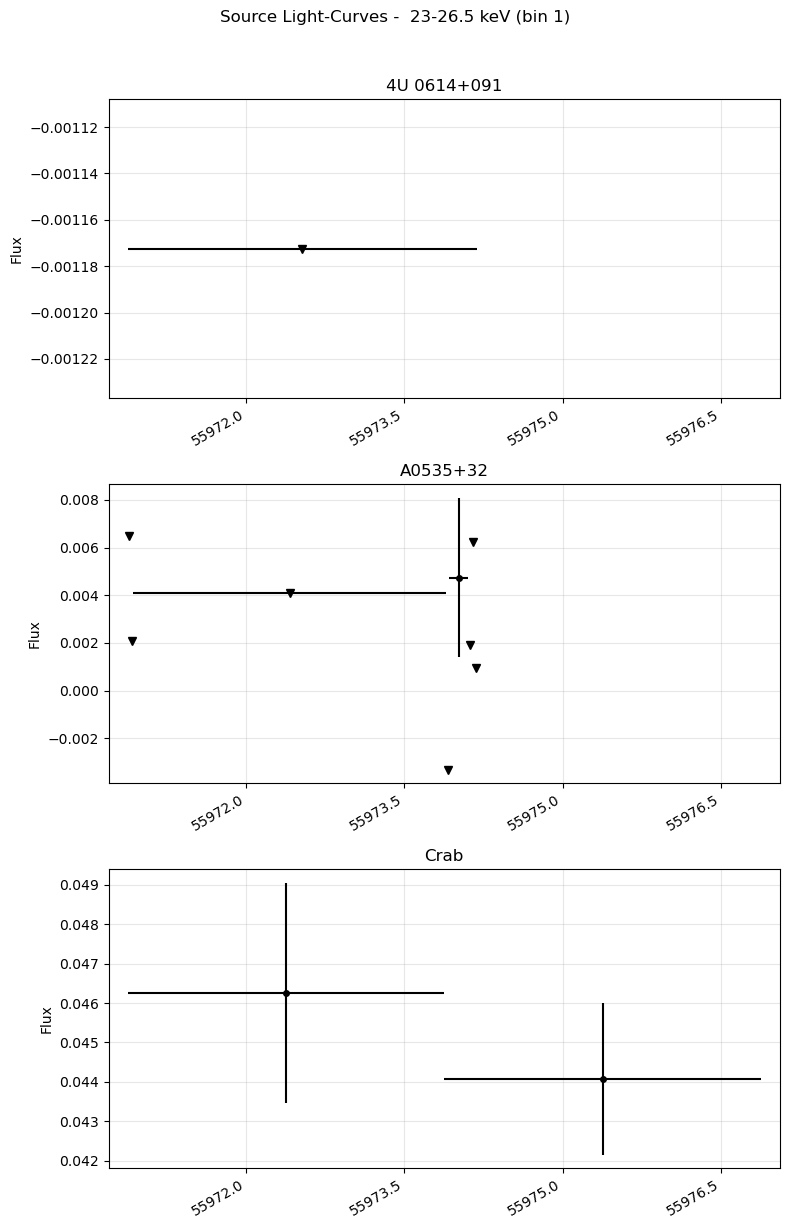

In [32]:
spec_path = obs.spec_path
# spec_path = "/home/tbouchet/SPI_SOURCES/obs/test/2005-01-01_2005-06-01_10deg/20_400_20log_SE/fit_1di_1pi"
spi_result = res.SPIResult(spec_path)
axes=spi_result.plot_source_lightcurves(energy_bin=1, ncols=1, share_dates=True, date_type='MJD', figsize_per_panel=(8,4))

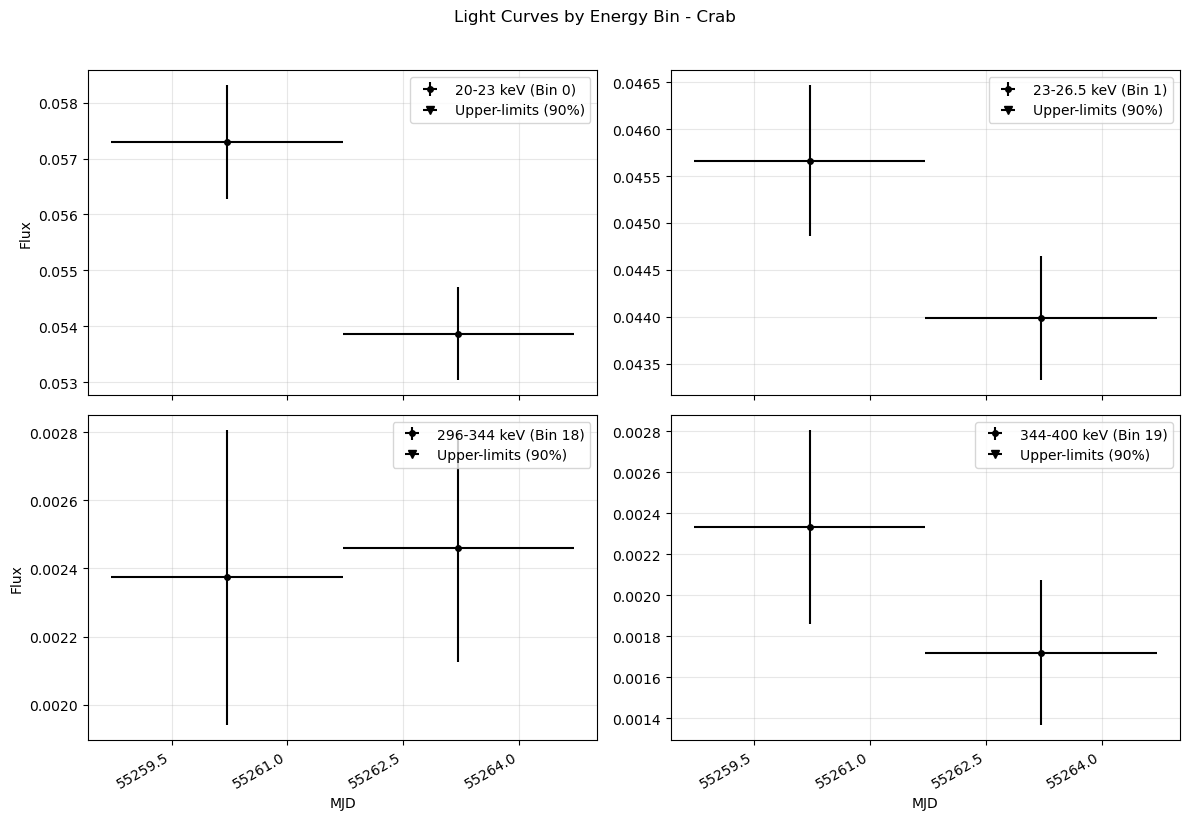

In [24]:
axes=spi_result.plot_energybin_lightcurves_for_source(
"Crab",
ncols=2,
date_type="MJD",
figsize_per_panel=(6, 4),
energy_bins=[0, 1, 18, 19],
show_uplim=True
)